# Modelo de regresion de gasolina

Importaciones iniciales para preparar los datos y construir el modelo.

In [6]:
from pathlib import Path
import sys

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from tensorflow import Tensor, keras
from tensorflow.keras import Input, Sequential, layers
from tensorflow.keras.layers import Dense

In [7]:
print("Version de Python:", sys.version)
print("Version de TensorFlow:", tf.__version__)
print("Version de Keras:", keras.__version__)

Version de Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
Version de TensorFlow: 2.20.0
Version de Keras: 3.13.2


In [12]:
# Descarga del dataset desde KaggleHub.
dataset_path = Path(kagglehub.dataset_download("yasserh/auto-mpg-dataset"))
csv_files = sorted(dataset_path.glob("*.csv"))

if not csv_files:
    raise FileNotFoundError(f"No se encontro ningun CSV en {dataset_path}")

dataset_file = next(
    (file for file in csv_files if file.stem.lower() == "auto-mpg"),
    csv_files[0],
)

# Cargar el dataset usando los nombres originales de sus columnas.
df = pd.read_csv(dataset_file)
df.columns = df.columns.str.strip()
df = df.replace("?", np.nan).drop_duplicates().copy()

df["horsepower"] = pd.to_numeric(df["horsepower"], errors="coerce")
horsepower_mean = df["horsepower"].mean()
df["horsepower"] = df["horsepower"].fillna(horsepower_mean)
df = df.dropna().copy()
df = df.drop(columns=["car name"], errors="ignore")

X = df.drop(columns=["mpg"])
y = df["mpg"].astype("float32")

print(f"Archivo cargado: {dataset_file}")
print(f"Columnas del dataset: {list(df.columns)}")
print(f"Media usada para horsepower: {horsepower_mean:.2f}")
print(f"Filas disponibles: {len(df)}")
print(f"Nulos restantes: {df.isnull().sum().sum()}")
df.head()

Using Colab cache for faster access to the 'auto-mpg-dataset' dataset.
Archivo cargado: /kaggle/input/auto-mpg-dataset/auto-mpg.csv
Columnas del dataset: ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model year', 'origin']
Media usada para horsepower: 104.47
Filas disponibles: 398
Nulos restantes: 0


,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin
0,18.0,8,307.0,130.0,3504,12.0,70,1
1,15.0,8,350.0,165.0,3693,11.5,70,1
2,18.0,8,318.0,150.0,3436,11.0,70,1
3,16.0,8,304.0,150.0,3433,12.0,70,1
4,17.0,8,302.0,140.0,3449,10.5,70,1


In [13]:
# Validar los datos y dividir variables independientes y dependiente.
X = X.copy()

if "model year" in X.columns:
    X["model year"] = pd.to_numeric(X["model year"], errors="coerce")

if "origin" in X.columns:
    X["origin"] = X["origin"].astype("string")

print("Columnas disponibles en X:", list(X.columns))
print("Nulos por columna en X:")
print(X.isnull().sum())

# Eliminar filas con nulos que hayan aparecido durante la conversion.
valid_rows = X.notna().all(axis=1) & y.notna()
X = X.loc[valid_rows].reset_index(drop=True)
y = y.loc[valid_rows].reset_index(drop=True)

# 80% entrenamiento y 20% prueba.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

# Separar una validacion del conjunto de entrenamiento sin tocar el test.
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
)

numeric_columns = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_columns = X_train.select_dtypes(exclude=np.number).columns.tolist()

# Mediana para columnas numericas y moda para columnas categoricas.
numeric_fill_values = X_train[numeric_columns].median()
categorical_fill_values = X_train[categorical_columns].mode().iloc[0]

def fill_missing_values(dataframe):
    result = dataframe.copy()
    result[numeric_columns] = result[numeric_columns].fillna(numeric_fill_values)
    result[categorical_columns] = result[categorical_columns].fillna(categorical_fill_values)
    return result

X_train_clean = fill_missing_values(X_train)
X_val_clean = fill_missing_values(X_val)
X_test_clean = fill_missing_values(X_test)

print("Nulos en X_train despues de imputar:", X_train_clean.isnull().sum().sum())
print("Forma X_train:", X_train_clean.shape)
print("Forma X_test:", X_test_clean.shape)
print("Caracteristica dependiente: mpg")
print("Caracteristicas independientes:", list(X.columns))

Columnas disponibles en X: ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model year', 'origin']
Nulos por columna en X:
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
dtype: int64
Nulos en X_train despues de imputar: 0
Forma X_train: (254, 7)
Forma X_test: (80, 7)
Caracteristica dependiente: mpg
Caracteristicas independientes: ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model year', 'origin']


In [14]:
# Codificar categorias y normalizar variables numericas.
try:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

X_train_categorical = encoder.fit_transform(X_train_clean[categorical_columns])
X_val_categorical = encoder.transform(X_val_clean[categorical_columns])
X_test_categorical = encoder.transform(X_test_clean[categorical_columns])

# La media y la desviacion se calculan unicamente con X_train.
scaler = StandardScaler()
X_train_numeric = scaler.fit_transform(X_train_clean[numeric_columns])
X_val_numeric = scaler.transform(X_val_clean[numeric_columns])
X_test_numeric = scaler.transform(X_test_clean[numeric_columns])

X_train_array = np.hstack([X_train_numeric, X_train_categorical]).astype("float32")
X_val_array = np.hstack([X_val_numeric, X_val_categorical]).astype("float32")
X_test_array = np.hstack([X_test_numeric, X_test_categorical]).astype("float32")

print("Media de X_train numerica normalizada:", X_train_numeric.mean(axis=0))
print("Desviacion de X_train numerica normalizada:", X_train_numeric.std(axis=0))
print("Forma de los datos para TensorFlow:", X_train_array.shape)

Media de X_train numerica normalizada: [-5.24514815e-17 -1.04902963e-16  9.44126667e-17  2.37780049e-16
 -3.42683012e-16 -9.30139605e-16]
Desviacion de X_train numerica normalizada: [1. 1. 1. 1. 1. 1.]
Forma de los datos para TensorFlow: (254, 9)


In [15]:
# Convertir los arreglos a tensores y crear datasets por lotes.
X_train_tensor = tf.convert_to_tensor(X_train_array, dtype=tf.float32)
X_val_tensor = tf.convert_to_tensor(X_val_array, dtype=tf.float32)
X_test_tensor = tf.convert_to_tensor(X_test_array, dtype=tf.float32)
y_train_tensor = tf.convert_to_tensor(y_train.to_numpy(), dtype=tf.float32)
y_val_tensor = tf.convert_to_tensor(y_val.to_numpy(), dtype=tf.float32)
y_test_tensor = tf.convert_to_tensor(y_test.to_numpy(), dtype=tf.float32)

train_dataset = tf.data.Dataset.from_tensor_slices((X_train_tensor, y_train_tensor))
train_dataset = train_dataset.shuffle(len(X_train_tensor), seed=42).batch(32)
val_dataset = tf.data.Dataset.from_tensor_slices((X_val_tensor, y_val_tensor)).batch(32)
test_dataset = tf.data.Dataset.from_tensor_slices((X_test_tensor, y_test_tensor)).batch(32)

print("Tipo de X_train_tensor:", X_train_tensor.dtype)
print("Forma de X_train_tensor:", X_train_tensor.shape)

Tipo de X_train_tensor: <dtype: 'float32'>
Forma de X_train_tensor: (254, 9)


In [16]:
# Modelo de regresion con tensores de TensorFlow.
model = Sequential(
    [
        Input(shape=(X_train_tensor.shape[1],), dtype=tf.float32),
        Dense(128, activation="relu"),
        layers.Dropout(0.20),
        Dense(64, activation="relu"),
        layers.Dropout(0.10),
        Dense(32, activation="relu"),
        Dense(1),
    ],
    name="modelo_regresion_mpg",
)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
    metrics=[
        keras.metrics.MeanAbsoluteError(name="mae"),
        keras.metrics.RootMeanSquaredError(name="rmse"),
    ],
)

model.summary()
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=100,
    callbacks=[keras.callbacks.EarlyStopping(patience=15, restore_best_weights=True)],
)

Model: "modelo_regresion_mpg"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,649 (45.50 KB)

 Trainable params: 11,649 (45.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 288ms/step - loss: 594.4274 - mae: 23.1011 - rmse: 24.3809 - val_loss: 612.7985 - val_mae: 23.3031 - val_rmse: 24.7548
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 557.4733 - mae: 22.2778 - rmse: 23.6109 - val_loss: 566.0525 - val_mae: 22.2716 - val_rmse: 23.7919
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 501.2432 - mae: 20.9763 - rmse: 22.3885 - val_loss: 491.6016 - val_mae: 20.5282 - val_rmse: 22.1721
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 410.3571 - mae: 18.6925 - rmse: 20.2573 - val_loss: 382.3107 - val_mae: 17.6891 - val_rmse: 19.5528
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 288.2214 - mae: 15.2254 - rmse: 16.9771 - val_loss: 240.9952 - val_mae: 13.7065 - val_rmse: 15.5240
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 150.1492 - mae: 10.6910 - rmse: 12.2535 - val_loss: 103.6729 - val_mae: 9.0650 - val_rmse: 10.1820
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - loss: 5.1303 - mae: 1.7607 - rmse: 2.2650
{'loss': 5.130283355712891, 'mae': 1.7607189416885376, 'rmse': 2.265012741088867}
   real_mpg  predicted_mpg
0      33.0      33.231316
1      28.0      31.509176
2      19.0      20.415983
3      13.0      15.328760
4      14.0      13.127116


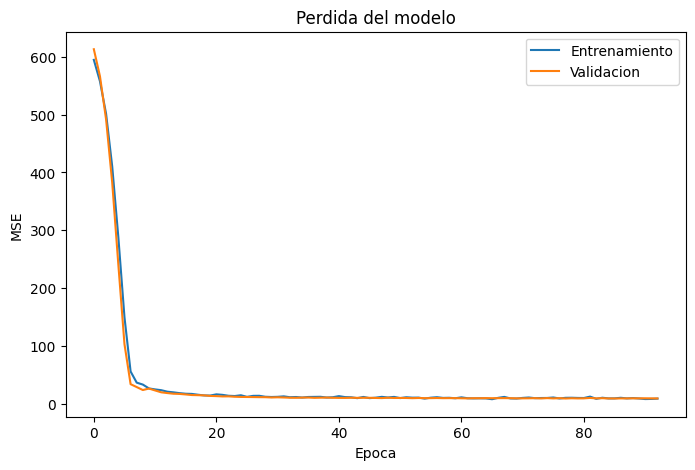

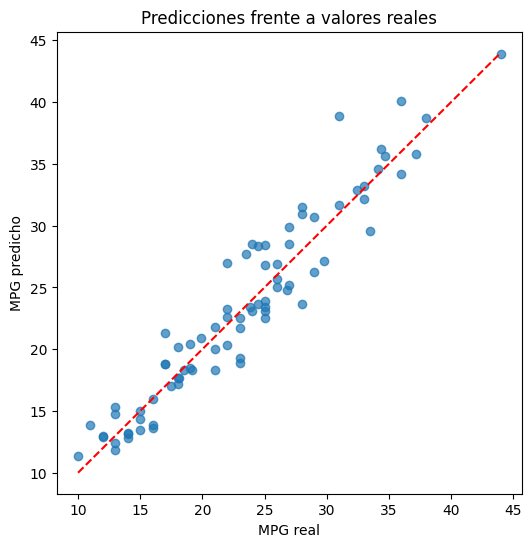

In [17]:
# Evaluacion, predicciones y graficas.
test_metrics = model.evaluate(test_dataset, return_dict=True)
print(test_metrics)

predictions = model.predict(X_test_tensor, verbose=0).reshape(-1)
results = pd.DataFrame(
    {"real_mpg": y_test.to_numpy(), "predicted_mpg": predictions}
)
print(results.head())

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Entrenamiento")
plt.plot(history.history["val_loss"], label="Validacion")
plt.xlabel("Epoca")
plt.ylabel("MSE")
plt.title("Perdida del modelo")
plt.legend()
plt.show()

plt.figure(figsize=(6, 6))
plt.scatter(results["real_mpg"], results["predicted_mpg"], alpha=0.7)
minimum = min(results.min())
maximum = max(results.max())
plt.plot([minimum, maximum], [minimum, maximum], "r--")
plt.xlabel("MPG real")
plt.ylabel("MPG predicho")
plt.title("Predicciones frente a valores reales")
plt.show()